# 06 — Desenho amostral espacial (`sampling`, `autocorrelation`)

Origem: `14_sample_design.R`, `SAMPLES_TO_POINTS.R` e `correlation_2.ipynb`.

## Fluxo

| Etapa | Função | Entrada → saída |
|---|---|---|
| 1 | `autocorrelation.sample_lags` | polígonos + imagem → lag h/v de cada polígono, por banda |
| 2 | `autocorrelation.summarize_lags` | → mediana e máximo sem outliers, por classe e banda |
| 3 | `autocorrelation.lags_for_sampling` | → maior lag entre as bandas, por classe (`h`, `v`) |
| 4 | `sampling.lag_grid_split` | raster de amostras + lags → pontos de treino/validação |
| 4' | `sampling.raster_samples_to_points` + `random_split_points` | alternativa aleatória |
| 5 | `sampling.extract_samples` | pontos + imagem → `df_samples` (entrada dos notebooks 02–05) |
| 6 | `sampling.save_points` | GeoPackage / Shapefile |

<details><summary><b>Correções e diferenças em relação aos originais</b></summary>

| Ponto | Original | Python |
|---|---|---|
| Velocidade da autocorrelação | 4 laços aninhados e grade 2D completa de lags (só a linha e a coluna eram usadas) | só os dois perfis, vetorizados: **~1.700× mais rápido** em um polígono de 60 × 60, com resultado idêntico |
| Leitura por polígono | `rio_mask` lia a **banda inteira** a cada polígono | lê só a janela do polígono |
| Variância da autocorrelação | dividia por `count_nonzero` (excluía pixels de valor 0 exato) | divide pelo nº de pixels válidos; idêntico quando não há zeros exatos |
| Transformação `**0.5` | embutida em `extrair_dados_raster`, sem aviso | parâmetro `value_transform='sqrt'` (padrão, como no original) |
| `balance` em `random_split_points` | a menor classe incluía o código 0 (nodata) | só classes válidas |
| Nomes das classes | `class_names[código]`; lags por **posição** na tabela | dict `{código: nome}` ou lista; lags por **nome** ou código |
| Arquivos | `paste(prefix, "train.shp")` inseria um **espaço** no nome; colunas `Class` × `Class_id` entre as duas funções | o caminho é informado por quem chama; colunas sempre `class_id`, `class_name` |
| `divide_data` | o parâmetro `class_name` só era usado na verificação; o agrupamento usava sempre a coluna `class_name` | `split_points(points, class_column, ...)` usa a coluna informada |
| `rgdal::writeOGR` | pacote retirado do CRAN | `geopandas` |

**Equivalência verificada:**
- Com o R, sobre os mesmos dados fictícios: pontos de `raster_to_points`, treino e validação por lags (**pixel a pixel**) e nº de amostras por classe na divisão aleatória.
- Com as funções originais de `correlation_2.ipynb`: lags de 80 de 80 recortes, incluindo polígonos com bordas parciais e nodata interno, e lags finais por classe.
</details>

In [1]:
import sys, tempfile
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))   # pasta que contém sar_classification

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
from rasterio.transform import from_origin
from sar_classification import (sampling, autocorrelation as ac, masking, transitions as trn, cmap,
                                trajectory_assessment as ta, models as mdl, raster_io as rio,
                                validation as val, fitting as fit, separability as sep, plots)

In [2]:
# ---------------------------------------------------------------------------------
# Cena fictícia: 4 classes em blocos, série de 3 datas (intensidade HH, Gama L = 4),
# textura espacial (speckle correlado), mudança de uma região entre as datas,
# raster de amostras (polígonos rasterizados) e máscara de nuvens.
# ---------------------------------------------------------------------------------
from scipy.ndimage import gaussian_filter
from shapely.geometry import box
import geopandas as gpd

rng = np.random.default_rng(2024)
WORK = Path(tempfile.mkdtemp())
H, W, RES = 120, 160, 12.5
TR = from_origin(300000, 7400000, RES, RES)
CRS = 'EPSG:31983'
classes = ['F', 'VS', 'PA', 'SE']
mu = {'F': 0.08, 'VS': 0.055, 'PA': 0.025, 'SE': 0.012}

truth0 = np.repeat(np.arange(4), W // 4)[None, :].repeat(H, axis=0)
truths = [truth0.copy(), truth0.copy(), truth0.copy()]
truths[1][:40, 40:80] = 2                       # VS -> PA (desmatamento) a partir da data 2
truths[2][:40, 40:80] = 2

def write(path, arr, dtype, nodata=None, desc=None):
    arr = arr if arr.ndim == 3 else arr[None]
    with rasterio.open(path, 'w', driver='GTiff', height=H, width=W, count=arr.shape[0], dtype=dtype,
                       crs=CRS, transform=TR, nodata=nodata) as dst:
        dst.write(arr.astype(dtype))
        for i, n in enumerate(desc or []):
            dst.set_band_description(i + 1, n)
    return path

images = []
for t, truth in enumerate(truths):
    tex = gaussian_filter(rng.normal(size=(H, W)), 2.0); tex = np.exp(0.6 * tex / tex.std())
    mean = np.array([mu[c] for c in classes])[truth] * tex
    images.append(write(WORK / f'HH_{2005 + t}.tif', rng.gamma(4.0, mean / 4.0), 'float32', desc=['HH']))

cloud = np.zeros((H, W), np.uint8); cloud[90:110, 100:140] = 1
write(WORK / 'nuvens.tif', cloud, 'uint8')

# polígonos de amostra (retângulos) e raster de amostras (códigos 1..4; 0 = fundo)
polys, labels, sample_r = [], [], np.zeros((H, W), np.int16)
for k, c in enumerate(classes):
    for _ in range(6):
        r0, c0 = rng.integers(45, H - 22), rng.integers(k * 40 + 1, k * 40 + 19)
        sample_r[r0:r0 + 20, c0:c0 + 20] = k + 1
        x0, y0 = TR * (c0, r0 + 20); x1, y1 = TR * (c0 + 20, r0)
        polys.append(box(x0, y0, x1, y1)); labels.append(c)
write(WORK / 'amostras_2005.tif', sample_r, 'int16', nodata=0)
polygons = gpd.GeoDataFrame({'Classe': labels}, geometry=polys, crs=CRS)
print('Arquivos fictícios em', WORK)

Arquivos fictícios em /tmp/tmpklvp8iqo


## 1. Autocorrelação espacial

Para cada polígono, com média $\bar{x}$ e variância $s^2$ dos pixels válidos:

$$R(d_x, d_y) = \frac{1}{s^2}\cdot\frac{1}{N(d_x,d_y)}\sum_{(p,q)} (x_p-\bar{x})(x_q-\bar{x})$$

sobre os $N$ pares de pixels válidos separados por $(d_x, d_y)$.

- O **perfil horizontal** usa $d_y = 0$ e $d_x = 0..k_1-1$, com $k_1 = \min(\lfloor n_{col}/3\rfloor + 2,\ 20)$.
- O **perfil vertical** é análogo, com $k_2$ calculado a partir de $n_{lin}$.
- O **lag de descorrelação** é o primeiro lag com $R <$ `target_correlation`.

| Função | Descrição |
|---|---|
| `autocorrelation_profiles(array, valid=None, max_lag=20)` | `(R_h, R_v, N_h, N_v)` |
| `decorrelation_lag(profile, target)` | primeiro lag abaixo do limiar (ou `None`) |
| `polygon_window(src, polygon, band, value_transform='sqrt')` | recorte; fora do polígono/nodata → NaN |
| `sample_lags(raster, polygons, class_column, bands=None, target_correlation=0.3, value_transform='sqrt')` | tabela polígono × banda |
| `plot_profiles(R_h, R_v, target, lag_h, lag_v, title)` | perfis espelhados |

> `value_transform='sqrt'` converte intensidade em amplitude, como no original. Se a imagem já estiver em amplitude, use `value_transform=None`. Pixels negativos são tratados como inválidos (regra do original), o que torna a função **inadequada para dados em dB** sem conversão prévia.

In [3]:
lags_poly = ac.sample_lags(images[0], polygons, 'Classe', target_correlation=0.3)
lags_poly.head()

24 recortes (polígonos x bandas); sem lag definido: h = 0, v = 0.


,polygon,class,band,lag_h,lag_v,n_valid
0,0,F,1,2,3,400
1,1,F,1,3,3,400
2,2,F,1,3,2,400
3,3,F,1,3,3,400
4,4,F,1,2,3,400


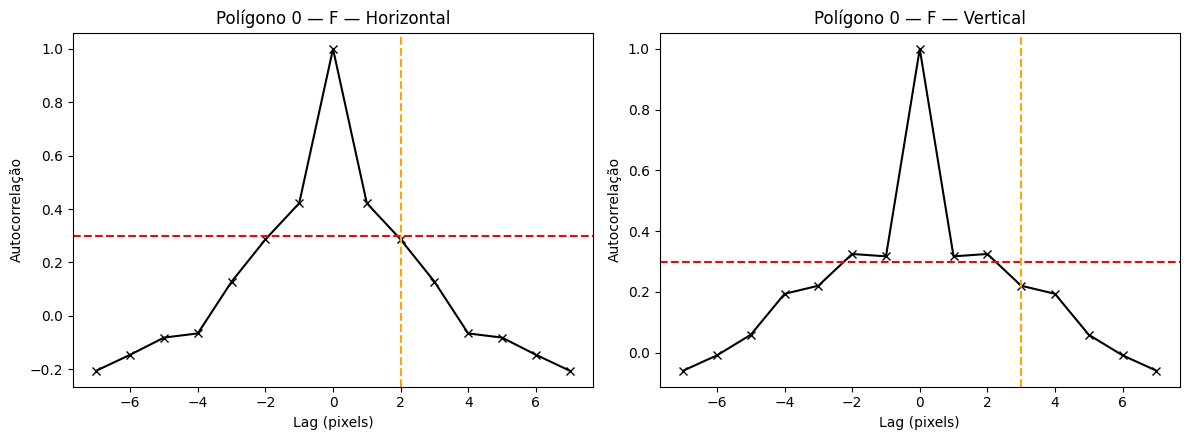

In [4]:
with rasterio.open(images[0]) as src:
    arr = ac.polygon_window(src, polygons.geometry.iloc[0], band=1)
R_h, R_v, _, _ = ac.autocorrelation_profiles(arr)
ac.plot_profiles(R_h, R_v, 0.3, ac.decorrelation_lag(R_h, 0.3), ac.decorrelation_lag(R_v, 0.3),
                 title=f"Polígono 0 — {polygons['Classe'].iloc[0]}")

## 2. Resumo e lags para amostragem

- `summarize_lags(lags, iqr=True)` calcula, por classe e banda, a mediana e o **máximo sem outliers**: o máximo dentro de $[Q_1 - 1{,}5\,IQR,\ Q_3 + 1{,}5\,IQR]$.
- `lags_for_sampling(summary, statistic='max')` toma o maior valor entre as bandas, como na célula `maiores_lags` do original.

In [5]:
summary = ac.summarize_lags(lags_poly)
lags = ac.lags_for_sampling(summary)
display(summary.round(2)); lags.T

,class,band,n_h,n_v,median_h,median_v,max_h,max_v
0,F,1,6,6,3.0,3.0,3.0,3.0
1,PA,1,6,6,3.0,3.0,3.0,3.0
2,SE,1,6,6,3.0,3.0,4.0,3.0
3,VS,1,6,6,3.0,3.0,3.0,3.0


class,F,PA,SE,VS
h,3,3,4,3
v,3,3,3,3


## 3. Amostragem por lags — `lag_grid_split(raster_path, class_names, lags, nodata_values=(0, -9999))`

Para cada classe, monta uma grade regular com passo de $h$ colunas e $v$ linhas, iniciada no canto **inferior esquerdo** (como no original):

- **treino:** pixels da classe que caem na grade, espaçados pelo lag de descorrelação;
- **validação:** os demais pixels da classe.

Com $h = v = 1$, a classe inteira vai para o treino.

> **Observação metodológica:** a validação reúne todos os pixels restantes, que são vizinhos imediatos dos pixels de treino e, portanto, correlacionados com eles. Isso tende a **otimizar** as métricas de validação. Mantive o comportamento original e registro o ponto para a sua avaliação.

In [6]:
train_pts, valid_pts = sampling.lag_grid_split(WORK / 'amostras_2005.tif', classes, lags)
pd.DataFrame({'treino': train_pts.class_name.value_counts(), 'validação': valid_pts.class_name.value_counts()})

,treino,validação
class_name,,
VS,181,1483
PA,176,1403
F,130,1019
SE,97,1002


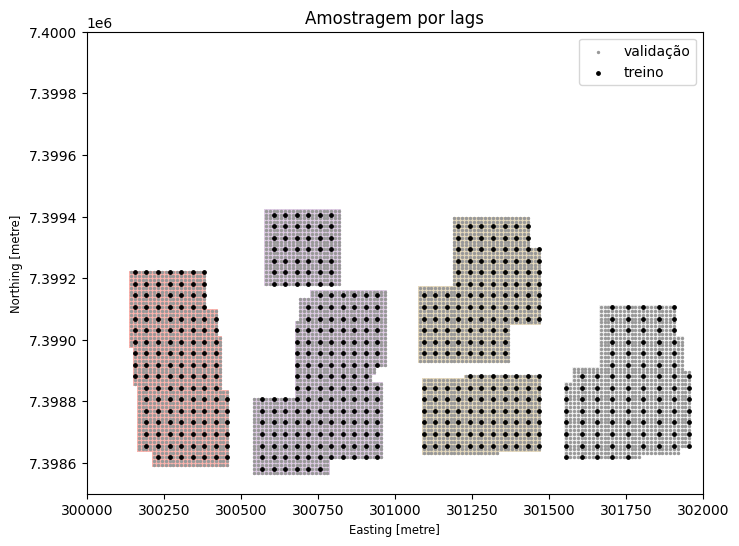

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
with rasterio.open(WORK / 'amostras_2005.tif') as s:
    ext = [s.bounds.left, s.bounds.right, s.bounds.bottom, s.bounds.top]
    ax.imshow(np.ma.masked_equal(s.read(1), 0), cmap='Pastel1', extent=ext, interpolation='nearest')
valid_pts.plot(ax=ax, markersize=2, color='0.6', label='validação')
train_pts.plot(ax=ax, markersize=6, color='k', label='treino')
ax.legend(); ax.set_title('Amostragem por lags'); plt.show()

## 4. Alternativa aleatória e divisão de pontos existentes

| Função | Regra |
|---|---|
| `raster_samples_to_points(raster, class_names, nodata_values=(0,))` | todos os pixels de amostra, no centro do pixel |
| `random_split_points(points, proportion, balance=None, random_state=None)` | treino = round(proportion × n) por classe; `balance=1` limita à menor classe; `balance=b` limita a b × menor classe |
| `split_points(points, class_column, train_ratio, random_state=None)` | treino = ⌊train_ratio × n⌋ por classe (`divide_data`) |

In [8]:
points = sampling.raster_samples_to_points(WORK / 'amostras_2005.tif', classes)
tr_r, va_r = sampling.random_split_points(points, 0.5, balance=1, random_state=1)
tr_r.class_name.value_counts().to_dict()

{'VS': 832, 'PA': 790, 'F': 574, 'SE': 550}

## 5. Pontos → conjunto amostral — `extract_samples(points, image_path, band_names=None, class_column='class_name')`

Lê os valores da imagem nos pontos (reprojetando os pontos, se necessário) e devolve o `df_samples` no formato dos notebooks 02–05. Pontos sem valor válido são descartados, com aviso. Os nomes das colunas vêm da descrição das bandas ou de `band_names`.

In [9]:
df_samples = sampling.extract_samples(train_pts, images[0])
sampling.save_points(train_pts, WORK / 'amostras' / 'treino_2005.gpkg')
df_samples.groupby('Class')['HH'].describe().round(4)

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
F,130.0,0.0929,0.0779,0.0085,0.0450,0.0808,0.1148,0.6445
PA,176.0,0.0311,0.0269,0.0023,0.0139,0.0230,0.0386,0.1574
SE,97.0,0.0159,0.0121,0.0016,0.0066,0.0126,0.0213,0.0688
VS,181.0,0.0702,0.0593,0.0039,0.0295,0.0540,0.0932,0.3860
